In [33]:
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt
from keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm

# reload import
import importlib

import src.preprocessing.gaussian_process as gp
import src.preprocessing.tools as tools
import src.preprocessing.plot_data as plot_data
import src.preprocessing.load_csv as load_csv

importlib.reload(plot_data)
importlib.reload(tools)
importlib.reload(gp)
importlib.reload(load_csv)

<module 'src.preprocessing.load_csv' from '/home/theob/Documents/stage/ML_project/ML_skyportal/src/preprocessing/load_csv.py'>

# Data Preprocessing

In [34]:
import numpy as np
import pandas as pd

def augment_data_with_noise(df, noise_level=0.05):
    new_entries = []
    flux_columns = ['mag', 'magerr']
    percentages = [80, 50, 20]

    for obj_id in tqdm(df['obj_id'].unique()):
        obj = df[df['obj_id'] == obj_id].sort_values('mjd').reset_index(drop=True)

        for percentage in percentages:
            subset_size = int((percentage / 100.0) * len(obj))
            
            subset_top = obj.iloc[:subset_size].copy()
            add_noise_and_append(subset_top, obj_id, percentage, 'top', new_entries, flux_columns, noise_level)
            
            subset_end = obj.iloc[-subset_size:].copy()
            add_noise_and_append(subset_end, obj_id, percentage, 'end', new_entries, flux_columns, noise_level)

    augmented_df = pd.concat([df] + new_entries, ignore_index=True)
    return augmented_df

def add_noise_and_append(subset, obj_id, percentage, prefix, entries_list, flux_columns, noise_level):
    key = f"{obj_id}_{prefix}_{percentage}"
    for col in flux_columns:
        noise = np.random.normal(0, noise_level * np.std(subset[col]), size=len(subset))
        subset[col] += noise
    subset['obj_id'] = key
    entries_list.append(subset)

In [4]:
def load_data(source):
    if isinstance(source, str):
        return pd.read_csv(source)
    return source

def preprocess_data(df):
    df['filter'] = df['filter'].replace({'sdssi': 'ztfi', 'sdssr': 'ztfr', 'sdssg': 'ztfg'})
    return df[df['filter'].isin(['ztfg', 'ztfr', 'ztfi'])]

def reset_data_indices(df):
    df = df.copy()
    df.reset_index(drop=True, inplace=True)
    #df['obj_id'] = '1'
    df['type'] = '?'
    return df

def augment_and_clean_data(df):
    df_aug = augment_data_with_noise(df)
    df_aug['mag'] = df_aug['mag'].apply(lambda x: max(x, 0))
    df_aug['magerr'] = df_aug['magerr'].apply(lambda x: max(x, 0))
    return df_aug

In [5]:
def prepare_gp_input(df):
    df = tools.Mag2Flux(df)
    df = tools.Normalize_mjd(df)
    return df

def apply_gaussian_process(df, kernel=None):
    return gp.process_gaussian(df, kernel=kernel, name='all')

def scale_gp_output(gp_df):
    scale_columns = [col for col in gp_df.columns if 'flux' in col]
    for col in scale_columns:
        if col not in gp_df.columns:
            gp_df[col] = -999.0
    return tools.robust_scale(gp_df, scale_columns)

In [6]:
def plot_photometry(df, relevant_ids):
    for obj_id in relevant_ids:
        one_df = df[df['obj_id'] == obj_id]
        plot_data.plot_photometry(one_df)

def predict_classes(gp_df, model):
    sequences = [group[['mjd', 'flux_ztfg', 'flux_ztfi', 'flux_ztfr']].values for _, group in gp_df.groupby('obj_id')]
    padded_sequences = pad_sequences(sequences, padding='post', dtype='float32')
    y_pred = model.predict(padded_sequences)
    return y_pred, np.argmax(y_pred, axis=1)

def display_predictions(y_pred, obj_ids, types):
    fig, axes = plt.subplots(y_pred.shape[0], 1, figsize=(10, 20))
    for i, ax in enumerate(axes):
        sns.barplot(x=types, y=y_pred[i], ax=ax)
        ax.set_title(f'Photometry {i + 1} - Obj ID: {obj_ids[i]}')
        ax.set_ylabel('Probability')
        display_value_on_bars(ax, y_pred[i])
    plt.tight_layout()
    plt.show()

def display_value_on_bars(ax, values):
    for p, value in zip(ax.patches, values):
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), f'{value:.2f}', 
                ha="center", va='bottom')

def weighted_average_predictions(y_pred, weights):
    valid_mask = ~np.isnan(y_pred).any(axis=1)
    valid_predictions = y_pred[valid_mask]
    valid_weights = weights[valid_mask]
    if valid_predictions.size > 0:
        return np.average(valid_predictions, axis=0, weights=valid_weights)
    return None

In [7]:
def final_prediction_display(final_prediction, types):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 4))
    sns.barplot(x=types, y=final_prediction, palette='viridis', hue=types)
    plt.title("Final Prediction by Mean")
    plt.ylabel("Mean Probability")
    plt.xlabel("Class")
    display_value_on_bars(plt.gca(), final_prediction)
    plt.show()

In [8]:
def predict_and_analyze(source, model):
    """
    Processes photometry data from source, applies Gaussian process modeling,
    makes predictions, and visualizes the results.

    Parameters:
        source (str or DataFrame): The file path to the data or a DataFrame.
        model (keras.Model): Trained model to make predictions.
        weights (list or np.array): Weights for averaging predictions.

    Returns:
        None
    """
    # Load and preprocess data
    df = load_data(source)
    df = preprocess_data(df)
    df = reset_data_indices(df)
    df = augment_and_clean_data(df)

    # Prepare data for Gaussian process
    df_gp_ready = prepare_gp_input(df)

    # Apply Gaussian process and scale the output
    gp_df = apply_gaussian_process(df_gp_ready)
    scale_columns = ['flux_ztfg', 'flux_ztfr', 'flux_ztfi', 'flux_error_ztfg', 'flux_error_ztfr', 'flux_error_ztfi']
    gp_df = scale_gp_output(gp_df, scale_columns)

    # Predict and plot photometry
    y_pred, y_pred_classes = predict_classes(gp_df, model)
    obj_ids = df['obj_id'].unique()
    types = ['Other', 'SN I', 'SN II']

    # Display predictions
    display_predictions(y_pred, obj_ids, types)

    # Calculate and display the weighted average prediction
    weights = np.array([0.4, 0.15, 0.15, 0.1, 0.1, 0.05, 0.05])
    final_prediction = weighted_average_predictions(y_pred, weights)
    if final_prediction is not None:
        final_prediction_display(final_prediction, types)
        final_class = np.argmax(final_prediction)
        print(f"Final Prediction by Mean:", final_prediction)
        print(f"Final Class by Voting:", types[final_class])
    else:
        print("No valid predictions available.")

In [9]:
# photometrty one obj
# metadata one obj
# images one obj

# photomtry augmente with 80, 50, 20 top and end

# need to copy and add noise to metadata to have the same number of objects
# need to copy and roatate or flip images to have the same number of objects

# Load Data

In [135]:
photo_df = pd.read_csv('data/photometry_Other_SN_I_SN_II.csv')
cand = pd.read_csv('data/train_cand_ZTFSS.csv')
triplets = np.load('data/train_triplets_ZTFSS.npy', mmap_mode='r')

columns_metadata = [
    "objectId",
    "sgscore1", "sgscore2", 
    "distpsnr1", "distpsnr2", 
    "fwhm", 
    "magpsf", 
    "sigmapsf", 
    "ra", 
    "dec", 
    "diffmaglim", 
    "ndethist", 
    "nmtchps", 
    "drb", 
    "ncovhist", 
    "sharpnr", 
    "scorr", 
    "sky"
]

cand = cand[columns_metadata]

cand_obj_ids = set(cand['objectId'].unique())
photo_obj_ids = set(photo_df['obj_id'].unique())
objIds = list(cand_obj_ids.intersection(photo_obj_ids))

In [10]:
def load_all_data(photo_path, cand_path, triplets_path):
    photo_df = pd.read_csv(photo_path)
    cand = pd.read_csv(cand_path)
    triplets = np.load(triplets_path, mmap_mode='r')
    
    columns_metadata = [
        "objectId",
        "sgscore1", "sgscore2", 
        "distpsnr1", "distpsnr2", 
        "fwhm", 
        "magpsf", 
        "sigmapsf", 
        "ra", 
        "dec", 
        "diffmaglim", 
        "ndethist", 
        "nmtchps", 
        "drb", 
        "ncovhist", 
        "sharpnr", 
        "scorr", 
        "sky"
    ]
    cand = cand[columns_metadata]

    cand_obj_ids = set(cand['objectId'].unique())
    photo_obj_ids = set(photo_df['obj_id'].unique())
    objIds = list(cand_obj_ids.intersection(photo_obj_ids))
    return photo_df, cand, triplets, objIds

In [11]:
def get_data(objId, photo_df, cand, triplets):
    one_cand = cand[cand['objectId'] == objId]
    one_image = triplets[one_cand.index[0]]
    one_photo = photo_df[photo_df['obj_id'] == objId]
    one_photo = one_photo.dropna()
    return one_photo, one_cand, one_image

In [12]:
def get_objId(objIds):
    return objIds[random.randint(0, len(objIds))]

In [13]:
def plot_all(one_photo, one_cand, one_image):
    plot_data.plot_photometry(one_photo)
    plot_data.plot_image(one_image)
    print(one_cand.head())

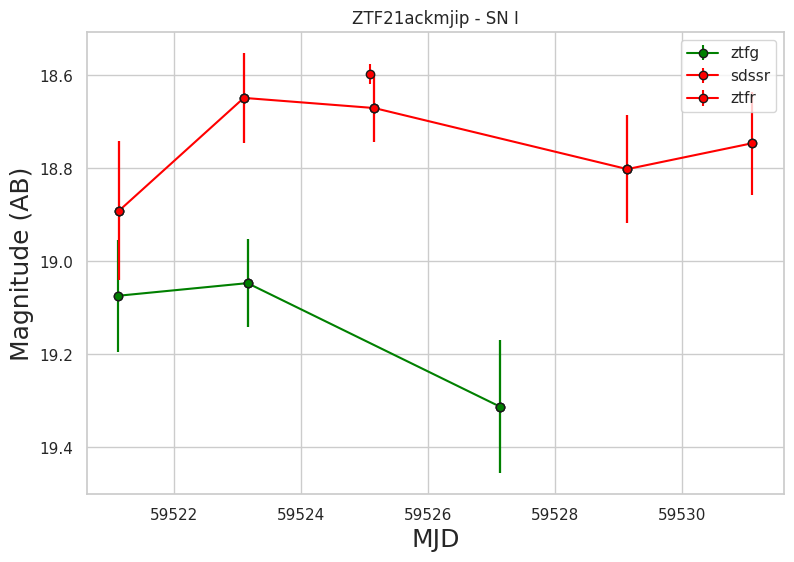

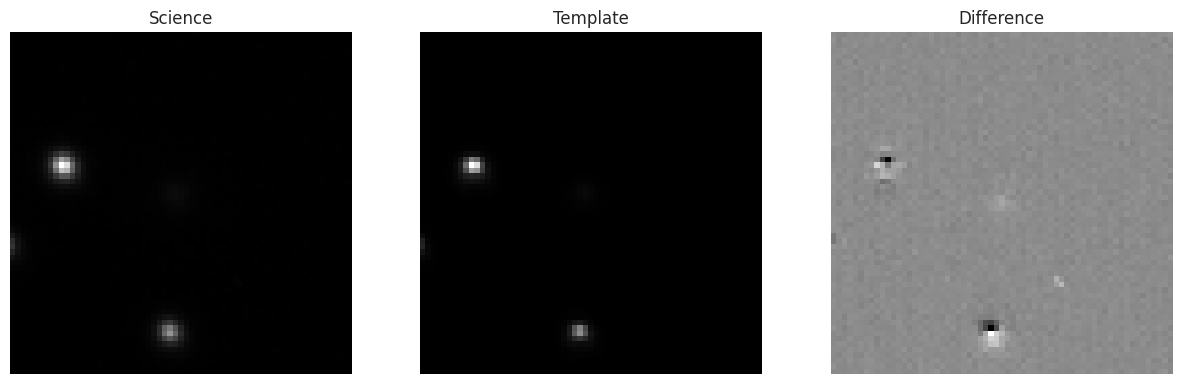

          objectId  sgscore1  sgscore2  distpsnr1  distpsnr2  fwhm    magpsf  \
2487  ZTF21ackmjip  0.071071  0.044125   2.161745   2.755741   2.6  18.74563   

      sigmapsf         ra        dec  diffmaglim  ndethist  nmtchps       drb  \
2487  0.110776  283.19787  35.740555   19.550865         9       15  0.999958   

      ncovhist  sharpnr     scorr       sky  
2487      2358    0.266  8.218659 -0.799441  


In [140]:
# get one object
objId = get_objId(objIds)
#objId = 'ZTF21abiacoi'
one_photo, one_cand, one_image = get_data(objId, photo_df, cand, triplets)
plot_all(one_photo, one_cand, one_image)

In [141]:
df = preprocess_data(one_photo)
df

,obj_id,mjd,mag,magerr,snr,limiting_mag,filter,type
3170913,ZTF21ackmjip,59521.124653,19.073700,0.120241,9.029667,19.715454,ztfg,SN I
3170914,ZTF21ackmjip,59521.124653,19.073700,0.120241,9.029667,20.486500,ztfg,SN I
3170915,ZTF21ackmjip,59521.136563,18.890669,0.149767,7.249510,19.294015,ztfr,SN I
3170916,ZTF21ackmjip,59521.136563,18.890669,0.149767,7.249510,20.423897,ztfr,SN I
3170917,ZTF21ackmjip,59521.136563,18.890700,0.149767,7.249502,19.294045,ztfr,SN I
3170918,ZTF21ackmjip,59523.100868,18.648239,0.095997,11.310084,19.534479,ztfr,SN I
3170919,ZTF21ackmjip,59523.100868,18.648239,0.095997,11.310084,20.598682,ztfr,SN I
3170920,ZTF21ackmjip,59523.100868,18.648200,0.095997,11.310106,19.534441,ztfr,SN I
3170921,ZTF21ackmjip,59523.159352,19.046566,0.095344,11.387521,19.940214,ztfg,SN I
3170922,ZTF21ackmjip,59523.159352,19.046566,0.095344,11.387521,20.465410,ztfg,SN I


# Preprocess

## Photometry

In [14]:
def plot_gp(obj_model, number_col=4, show_title=True, show_legend=True):
    color_dict = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'yellow'}
    
    # Plot the main plot
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plotting model data if available
    if obj_model is not None:
        for column in obj_model.columns:
            if 'flux' in column and column != 'mjd':
                filter_name = column.split('_')[1]
                if filter_name in color_dict:
                    if not all(obj_model[column] == -1):
                        ax1.plot(obj_model['mjd'], obj_model[column], label=f'Model {filter_name}', color=color_dict[filter_name])
                        
                        error_column = f'flux_error_{filter_name}'
                        if error_column in obj_model.columns:
                            model_flux_error = obj_model[error_column]
                            ax1.fill_between(obj_model['mjd'], obj_model[column]-model_flux_error, obj_model[column]+model_flux_error, color=color_dict[filter_name], alpha=0.20)
    
    ax1.set_xlabel('Time (mjd)')
    ax1.set_ylabel('Flux')
    if show_title:
        obj_id = obj_model['obj_id'].iloc[0]
        ax1.set_title(f'Light Curve for Object ID: {obj_id} | Type: {obj_model["type"].iloc[0]}')
    if show_legend:
        ax1.legend(ncol=number_col)
    
    plt.show()
    
    # Plot the smaller plots in a 3x2 grid
    fig2, axes = plt.subplots(3, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes[:6]):  # Only take the first 6 axes
        # Plotting model data if available
        if obj_model is not None:
            for column in obj_model.columns:
                if 'flux' in column and column != 'mjd':
                    filter_name = column.split('_')[1]
                    if filter_name in color_dict:
                        if not all(obj_model[column] == -1):
                            ax.plot(obj_model['mjd'], obj_model[column], label=f'Model {filter_name}', color=color_dict[filter_name])
                            
                            error_column = f'flux_error_{filter_name}'
                            if error_column in obj_model.columns:
                                model_flux_error = obj_model[error_column]
                                ax.fill_between(obj_model['mjd'], obj_model[column]-model_flux_error, obj_model[column]+model_flux_error, color=color_dict[filter_name], alpha=0.20)
        
        ax.set_xlabel('Time (mjd)')
        ax.set_ylabel('Flux')
        if show_title:
            ax.set_title(f'Plot {i+1}')
        if show_legend:
            ax.legend(ncol=number_col)
    
    plt.tight_layout()
    plt.show()

In [15]:
def plot_light_curve(ax, data, color_dict, show_title, show_legend, number_col):
    for column in data.columns:
        if 'flux' in column and column != 'mjd':
            filter_name = column.split('_')[1]
            if filter_name in color_dict:
                if not all(data[column] == -1):
                    ax.plot(data['mjd'], data[column], label=f'Model {filter_name}', color=color_dict[filter_name])

                    error_column = f'flux_error_{filter_name}'
                    if error_column in data.columns:
                        model_flux_error = data[error_column]
                        ax.fill_between(data['mjd'], data[column] - model_flux_error, data[column] + model_flux_error, color=color_dict[filter_name], alpha=0.20)

    ax.set_xlabel('Time (mjd)')
    ax.set_ylabel('Flux')
    if show_title:
        obj_id = data['obj_id'].iloc[0]
        obj_type = data['type'].iloc[0]
        ax.set_title(f'Light Curve for Object ID: {obj_id} | Type: {obj_type}')
    if show_legend:
        ax.legend(ncol=number_col)

def plot_gp_separated_by_obj_id(df, number_col=4, show_title=True, show_legend=True):
    color_dict = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'yellow'}
    
    obj_ids = df['obj_id'].unique()
    
    obj_model = df[df['obj_id'] == obj_ids[0]]
    
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    plot_light_curve(ax1, obj_model, color_dict, show_title, show_legend, number_col)
    plt.show()
    
    remaining_obj_ids = obj_ids[obj_ids != obj_ids[0]][:6]
    fig2, axes = plt.subplots(3, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for ax, rem_obj_id in zip(axes, remaining_obj_ids):
        rem_obj_model = df[df['obj_id'] == rem_obj_id]
        plot_light_curve(ax, rem_obj_model, color_dict, show_title, show_legend, number_col)
    
    plt.tight_layout()
    plt.show()

In [16]:
def preprocess_photo(one_photo, verbose=False):
    df = preprocess_data(one_photo)
    df = reset_data_indices(df)
    df = augment_and_clean_data(df)

    df_gp_ready = prepare_gp_input(df)

    columns = ['obj_id', 'mjd', 'flux_ztfg', 'flux_ztfi', 'flux_ztfr', 
           'flux_error_ztfg', 'flux_error_ztfi', 'flux_error_ztfr']

    final_gp = pd.DataFrame(columns=columns)
    for i in df_gp_ready['obj_id'].unique():
        one_gp = df_gp_ready[df_gp_ready['obj_id'] == i]
        gp_df = apply_gaussian_process(one_gp)
        gp_df = scale_gp_output(gp_df)
        final_gp = pd.concat([final_gp, gp_df], ignore_index=True)


    final_gp.fillna(0., inplace=True)

    if verbose:
        plot_gp_separated_by_obj_id(final_gp)
    
    return final_gp

100%|██████████| 1/1 [00:00<00:00, 109.23it/s]


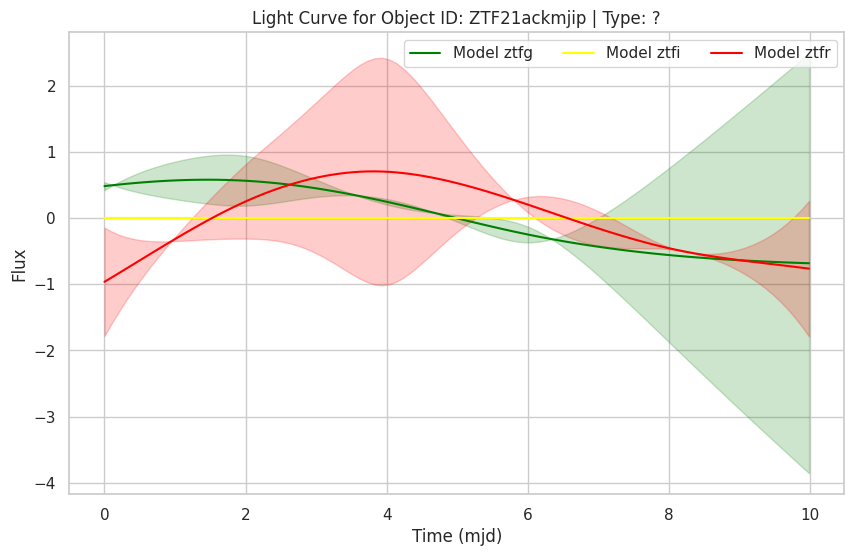

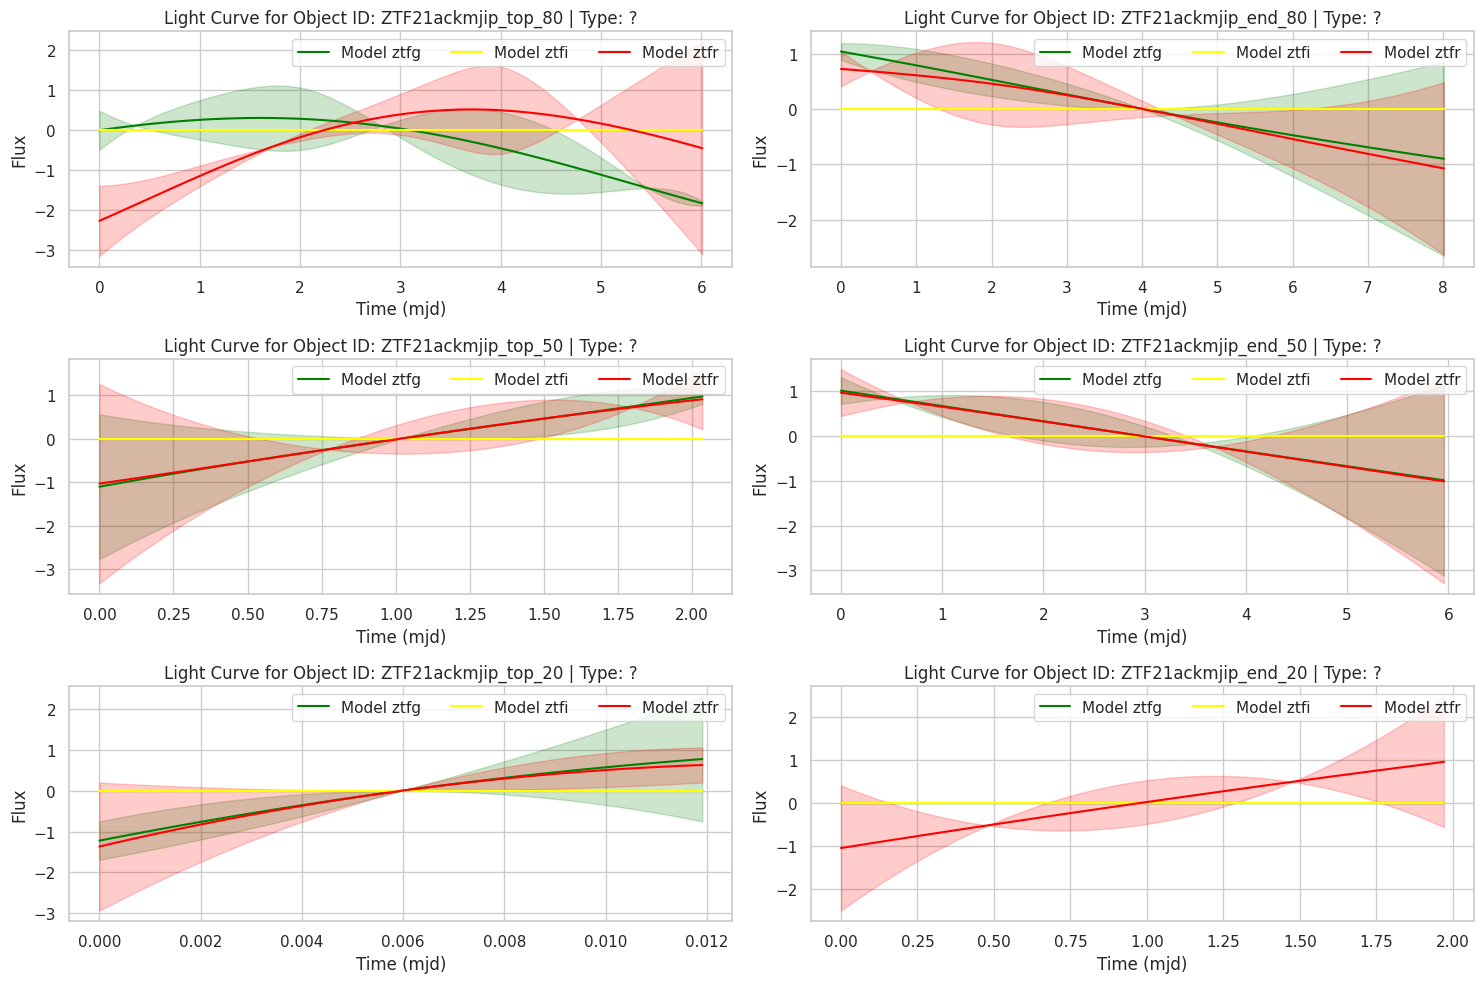

In [148]:
photo_ready = preprocess_photo(one_photo, verbose=True)

In [149]:
photo_ready

,obj_id,mjd,flux_ztfg,flux_ztfi,flux_ztfr,flux_error_ztfg,flux_error_ztfi,flux_error_ztfr,type
0,ZTF21ackmjip,0.000000,0.486133,0.0,-0.961527,0.061364,0.0,0.819382,?
1,ZTF21ackmjip,0.100865,0.498247,0.0,-0.897107,0.008639,0.0,0.696532,?
2,ZTF21ackmjip,0.201730,0.509669,0.0,-0.832082,-0.038797,0.0,0.584719,?
3,ZTF21ackmjip,0.302595,0.520374,0.0,-0.766612,-0.081439,0.0,0.482951,?
4,ZTF21ackmjip,0.403461,0.530335,0.0,-0.700856,-0.119800,0.0,0.390179,?
...,...,...,...,...,...,...,...,...,...
695,ZTF21ackmjip_end_20,1.891082,0.000000,0.0,0.874059,0.000000,0.0,1.202413,?
696,ZTF21ackmjip_end_20,1.910988,0.000000,0.0,0.892242,0.000000,0.0,1.277756,?
697,ZTF21ackmjip_end_20,1.930894,0.000000,0.0,0.910380,0.000000,0.0,1.354722,?
698,ZTF21ackmjip_end_20,1.950800,0.000000,0.0,0.928474,0.000000,0.0,1.433310,?


In [19]:
new_ids = photo_ready[photo_ready['obj_id'].str.contains('_')]['obj_id'].unique()

print(new_ids)

['ZTF21abiacoi_top_80' 'ZTF21abiacoi_end_80' 'ZTF21abiacoi_top_50'
 'ZTF21abiacoi_end_50' 'ZTF21abiacoi_top_20']


## Metadata

In [17]:
def preprocess_cand(one_cand, new_ids):
    columns_metadata_nb = one_cand.columns.difference(['objectId'])
    original_id = one_cand['objectId'].iloc[0]

    cand_ready = one_cand.copy()

    for new_id in new_ids:    
        row_to_copy = one_cand[one_cand['objectId'] == original_id].iloc[0].copy()
        # Add noise to metadata
        for col in columns_metadata_nb:
            row_to_copy[col] += 0.05 * np.random.randn() * row_to_copy[col]
        row_to_copy['objectId'] = new_id
        cand_ready = pd.concat([cand_ready, pd.DataFrame([row_to_copy])], ignore_index=True)

    cand_ready = tools.robust_scale(cand_ready, columns_metadata_nb)

    return cand_ready

In [37]:
cand_ready = preprocess_cand(one_cand, new_ids)
cand_ready

,objectId,sgscore1,sgscore2,distpsnr1,distpsnr2,fwhm,magpsf,sigmapsf,ra,dec,diffmaglim,ndethist,nmtchps,drb,ncovhist,sharpnr,scorr,sky
0,ZTF21abiacoi,0.061765,-0.100455,0.296841,-0.072812,-0.849237,-0.177863,0.222027,-0.058866,0.271111,0.338876,-0.695809,-0.139013,-0.148515,-0.018131,-0.520602,-0.894079,-0.141701
1,ZTF21abiacoi_top_80,1.122464,1.070350,2.209785,-0.671859,0.532817,1.197142,0.951563,0.307758,-0.218446,-0.699622,0.438600,0.139013,0.428343,0.018131,0.588655,0.335697,-0.187974
2,ZTF21abiacoi_end_80,-0.295424,0.100455,0.701916,0.612933,0.390865,0.177863,-0.550306,0.058866,0.218446,0.557543,-0.298387,0.460882,-0.805980,-4.161374,0.336114,0.318848,1.957254
3,ZTF21abiacoi_top_50,-0.337103,-0.611557,-0.296841,0.072812,-0.139847,-1.120039,-0.222027,-0.986331,0.626432,-0.338876,1.185224,-0.779776,1.161089,0.093787,-1.341916,-2.085885,0.141701
4,ZTF21abiacoi_end_50,-0.061765,-0.736057,-3.492132,-0.753538,0.139847,0.838458,0.759489,1.528752,-1.192677,0.407794,-2.003473,1.019626,-1.128329,-1.227459,1.422017,-0.180610,1.050891
5,ZTF21abiacoi_top_20,0.996733,0.654807,-0.433523,1.438375,-2.311683,-0.376301,-0.425826,-1.752821,-0.916592,-0.804689,0.298387,-2.219250,0.148515,0.705723,-0.336114,0.180610,-1.767995


## Images

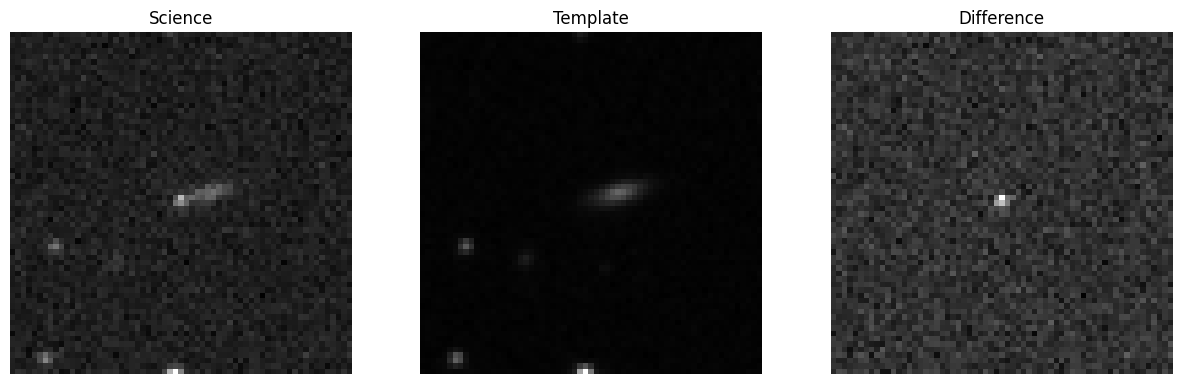

In [24]:
plot_data.plot_image(one_image)

In [25]:
one_image.shape

(63, 63, 3)

In [18]:
def rotate(image, angle):
        return np.rot90(image, k=int(angle / 90))

def flip_and_rotate(image, angle):
    image_rotated = rotate(image, angle)
    return np.flipud(image_rotated)

def normalize_images(images):
    min_val = images.min()
    max_val = images.max()
    normalized_images = 2 * (images - min_val) / (max_val - min_val) - 1
    return normalized_images

def preprocess_image(one_image, new_ids, verbose=False):

    image_ready = [one_image]

    nb_length = len(new_ids)

    transformations = [
        lambda x: rotate(x, 90),
        lambda x: rotate(x, 180),
        lambda x: rotate(x, 270),
        lambda x: flip_and_rotate(x, 90),
        lambda x: flip_and_rotate(x, 180),
        lambda x: flip_and_rotate(x, 270)
    ]
    
    # Apply transformations
    for i in range(nb_length):
        transform = transformations[i % len(transformations)]
        transformed_image = transform(one_image)
        image_ready.append(transformed_image)

    # Normalize images
    image_ready = normalize_images(np.array(image_ready))

    if verbose:
        for i, image in enumerate(image_ready):
            plot_data.plot_image(image)

    return image_ready

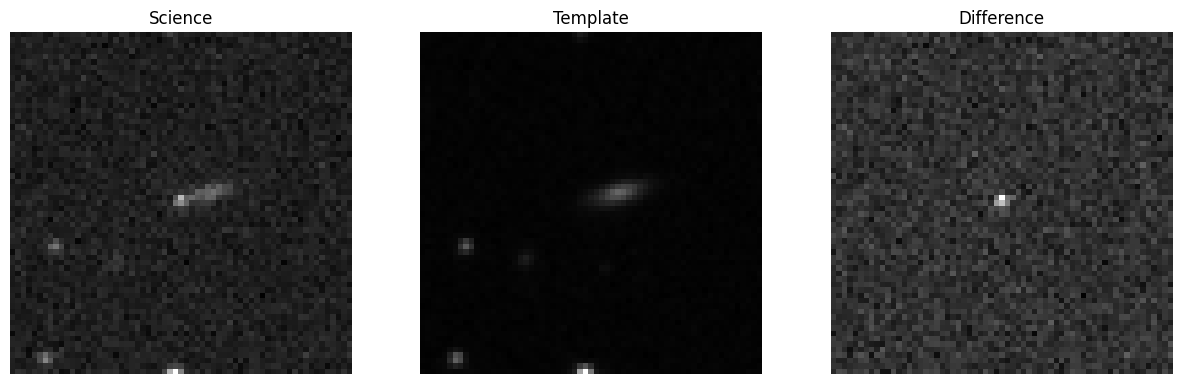

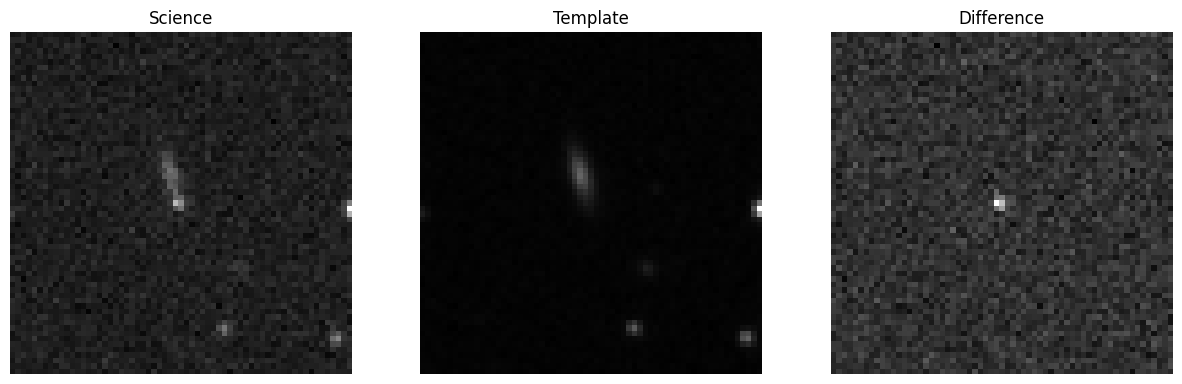

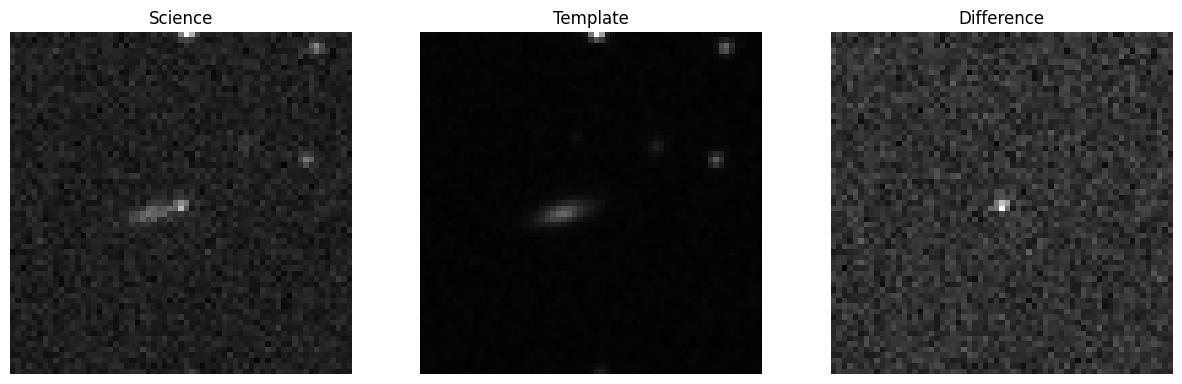

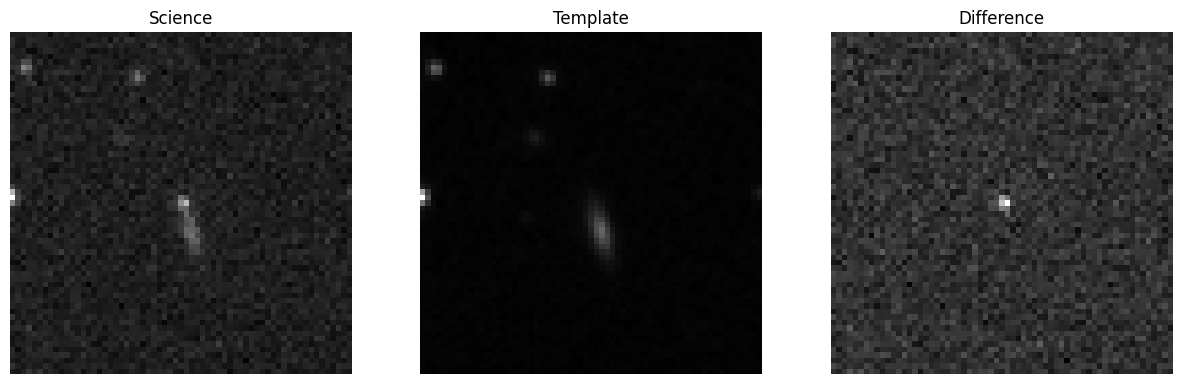

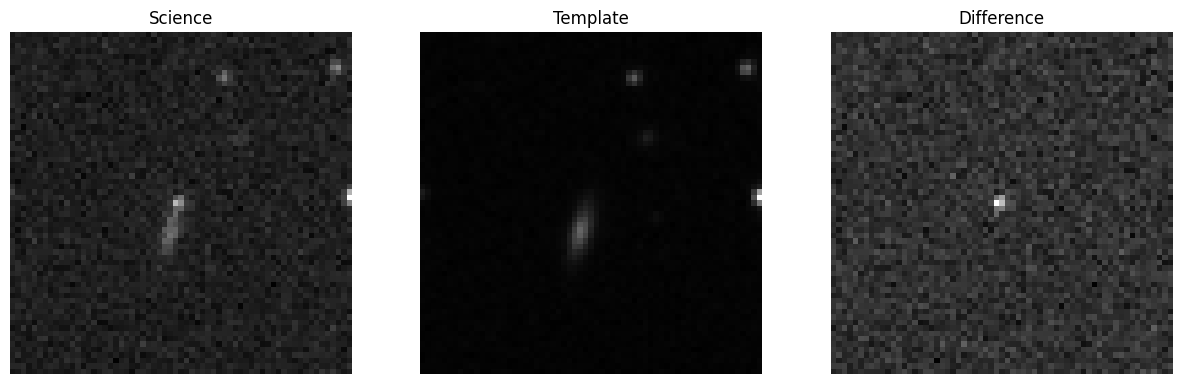

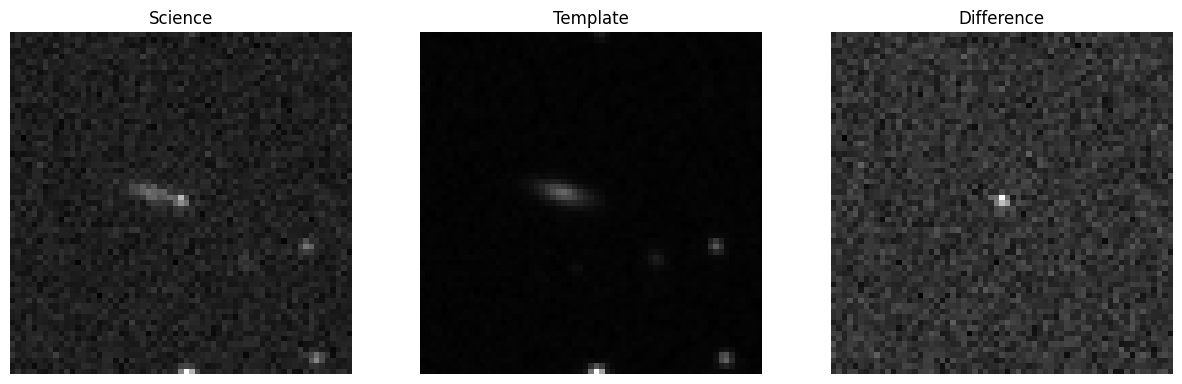

In [63]:
image_ready = preprocess_image(one_image, new_ids, verbose=True)

# All

In [19]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot
import numpy as np
from tensorflow.keras.utils import register_keras_serializable

class PrunableClusterableLayer(
    tf.keras.layers.Layer,
    tfmot.sparsity.keras.PrunableLayer,
    tfmot.clustering.keras.ClusterableLayer,
):
    def get_prunable_weights(self):
        # Prune kernel only, as pruning bias can harm model accuracy.
        return [self.conv1d.kernel]

    def get_clusterable_weights(self):
        # Cluster only the kernel as clustering bias usually harms model accuracy.
        return [("kernel", self.conv1d.kernel)]

    def get_clusterable_algorithm(self, weight_name):
        # Example algorithm, customize as necessary
        if weight_name == "kernel":
            return tfmot.clustering.keras.cluster_config.CentroidInitialization.LINEAR
        else:
            return None
        
class ConvEmbedding(PrunableClusterableLayer):
    def __init__(self, num_filters, kernel_size=1, activation='relu', **kwargs):
        super(ConvEmbedding, self).__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.activation = activation
        self.conv1d = layers.Conv1D(
            filters=self.num_filters, kernel_size=self.kernel_size, activation=self.activation, padding='same'
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "activation": self.activation,
        })
        return config

    def call(self, inputs):
        return self.conv1d(inputs)
    
class PositionalEncoding(PrunableClusterableLayer):
    def __init__(self, max_steps, max_dims, dtype=tf.float32, **kwargs):
        super(PositionalEncoding, self).__init__(dtype=dtype, **kwargs)
        self.max_steps = max_steps
        self.max_dims = max_dims

        if max_dims % 2 == 1:
            max_dims += 1
        p, i = np.meshgrid(np.arange(max_steps), np.arange(max_dims // 2))
        pos_emb = np.empty((1, max_steps, max_dims))
        pos_emb[0, :, ::2] = np.sin(p / 10000 ** (2 * i / max_dims)).T
        pos_emb[0, :, 1::2] = np.cos(p / 10000 ** (2 * i / max_dims)).T
        self.positional_embedding = tf.constant(pos_emb.astype(np.float32))

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_steps": self.max_steps,
            "max_dims": self.max_dims,
        })
        return config

    def call(self, inputs):
        shape = tf.shape(inputs)
        return inputs + self.positional_embedding[:, :shape[1], :shape[2]]
    
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError(f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
    
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)

        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output
    
class TransformerBlock(PrunableClusterableLayer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim

        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"), 
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
        })
        return config

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class ImageProcessor(tf.keras.layers.Layer):
    def __init__(self):
        super(ImageProcessor, self).__init__()
        self.conv1 = layers.Conv2D(32, (5, 5), activation='relu', padding="same")
        self.conv2 = layers.Conv2D(32, (5, 5), activation='relu', padding="same")
        self.pool1 = layers.MaxPooling2D(pool_size=(2, 2))
        self.drop1 = layers.Dropout(0.50)
        self.conv3 = layers.Conv2D(64, (5, 5), activation='relu', padding="same")
        self.conv4 = layers.Conv2D(64, (5, 5), activation='relu', padding="same")
        self.pool2 = layers.MaxPooling2D(pool_size=(4, 4))
        self.drop2 = layers.Dropout(0.55)
        self.flatten = layers.Flatten()

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.drop1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.drop2(x)
        return self.flatten(x)

class MetadataProcessor(tf.keras.layers.Layer):
    def __init__(self):
        super(MetadataProcessor, self).__init__()
        self.batch_norm = layers.BatchNormalization()
        self.dense1 = layers.Dense(128, activation='relu')
        self.drop1 = layers.Dropout(0.25)
        self.dense2 = layers.Dense(128, activation='relu')

    def call(self, inputs):
        y = self.batch_norm(inputs)
        y = self.dense1(y)
        y = self.drop1(y)
        return self.dense2(y)

class MultimodalModel(tf.keras.Model):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        self.image_processor = ImageProcessor()
        self.metadata_processor = MetadataProcessor()
        self.concat = layers.Concatenate()
        self.final_dense1 = layers.Dense(8, activation='relu')
        self.dropout = layers.Dropout(0.20)
        self.final_dense2 = layers.Dense(1)

    def call(self, inputs):
        images, metadata = inputs
        processed_images = self.image_processor(images)
        processed_metadata = self.metadata_processor(metadata)
        combined = self.concat([processed_images, processed_metadata])
        x = self.final_dense1(combined)
        x = self.dropout(x)
        return self.final_dense2(x)
    
@register_keras_serializable()
class T2Model(tf.keras.Model):
    def __init__(self, num_filters, num_classes, num_layers, d_model, num_heads, dff, input_shapes, rate=0.1):
        super(T2Model, self).__init__()
        self.num_filters = num_filters
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.rate = rate

        self.multimodal_model = MultimodalModel()

        # Transformer components for photometry
        self.embedding = ConvEmbedding(num_filters=self.num_filters, kernel_size=3, activation='relu')
        self.pos_encoding = PositionalEncoding(max_steps=input_shapes[0][0], max_dims=d_model)
        self.encoder_layers = [TransformerBlock(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.dropout = layers.Dropout(rate)
        self.concat = layers.Concatenate(axis=-1)
        self.final_layer = layers.Dense(num_classes, activation='sigmoid')

    def call(self, inputs, training=False):
        photometry, metadata, image = inputs

        x = self.embedding(photometry)
        x = self.pos_encoding(x)

        for layer in self.encoder_layers:
            x = layer(x, training=training)

        x = layers.GlobalAveragePooling1D()(x)

        multimodal_output = self.multimodal_model([image, metadata])
        x = self.concat([x, multimodal_output])
        x = self.dropout(x, training=training)
        return self.final_layer(x)

    def build(self, input_shapes):
        photometry = tf.keras.Input(shape=input_shapes[0], name="photometry_input")
        metadata = tf.keras.Input(shape=input_shapes[1], name="metadata_input")
        images = tf.keras.Input(shape=input_shapes[2], name="image_input")
        _ = self.call([photometry, metadata, images])

from tensorflow.keras.optimizers import Adam

num_filters = 64
num_classes = 2
num_layers = 1
d_model = 64
num_heads = 16
dff = 128
rate = 0.5

shapes = [(100, 4), (17,), (63, 63, 3)]

# Initialize the T2Model with the proper configuration
model = T2Model(num_filters=num_filters, num_classes=num_classes, num_layers=num_layers,
                d_model=d_model, num_heads=num_heads, dff=dff, input_shapes=shapes, 
                rate=rate)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

# Creating the final model instance
model.build(input_shapes=shapes)

# Print the model summary
model.summary()

model.load_weights('checkpoints/step_1.weights.h5')

2024-06-05 15:12:34.031825: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-05 15:12:34.076246: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "t2_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multimodal_model                │ (None, 1)              │       226,805 │
│ (MultimodalModel)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_embedding (ConvEmbedding)  │ (None, 100, 64)        │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 100, 64)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 65)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_1 (Concatenate)     │ (None, 65)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,241 (1020.47 KB)

 Trainable params: 261,207 (1020.34 KB)

 Non-trainable params: 34 (136.00 B)

/home/theob/anaconda3/envs/ml_skyportal_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:396: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


In [20]:
def process_data(one_photo, one_cand, one_image, verbose=False):
    photo_ready = preprocess_photo(one_photo, verbose)
    new_ids = photo_ready[photo_ready['obj_id'].str.contains('_')]['obj_id'].unique()
    cand_ready = preprocess_cand(one_cand, new_ids)
    image_ready = preprocess_image(one_image, new_ids)
    
    return photo_ready, cand_ready, image_ready

# Here

In [23]:
photo_df, cand, triplets, objIds = load_all_data('data/photometry_Other_SN_I_SN_II.csv', 'data/train_cand_ZTFSS.csv', 'data/train_triplets_ZTFSS.npy')

In [24]:
objId = 'ZTF21abiacoi'
one_photo, one_cand, one_image = get_data(objId, photo_df, cand, triplets)
real_type = one_photo['type'].iloc[0]
print(f"Real Type: {real_type}")
plot_all(one_photo, one_cand, one_image)

Real Type: SN I


In [71]:
photo_ready, cand_ready, image_ready = process_data(one_photo, one_cand, one_image)

100%|██████████| 1/1 [00:00<00:00, 40.15it/s]


In [21]:
def predict_classes(photo_ready, cand_ready, image_ready):
    # photometry
    sequences = [group[['mjd', 'flux_ztfg', 'flux_ztfi', 'flux_ztfr']].values for _, group in photo_ready.groupby('obj_id')]
    padded_sequences = pad_sequences(sequences, padding='post', dtype='float32')

    # metadata
    metadata = cand_ready.drop(columns='objectId')

    final_data = [padded_sequences, metadata, image_ready]

    return final_data

In [73]:
final_data = predict_classes(photo_ready, cand_ready, image_ready, model)

In [74]:
final_data[0].shape, final_data[1].shape, final_data[2].shape

((6, 100, 4), (6, 17), (6, 63, 63, 3))

In [22]:
def predict_T2(final_data, model):
    y_pred = model.predict(final_data)

    return y_pred, np.argmax(y_pred, axis=1)

In [85]:
# predict
y_pred, y_pred_classes = predict_T2(final_data, model)

y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[8.7314413e-09, 9.9999982e-01],
       [1.5315163e-06, 9.9998206e-01],
       [1.5474628e-08, 9.9999958e-01],
       [7.6389093e-05, 9.9818581e-01],
       [1.0920230e-07, 9.9999690e-01],
       [3.6665714e-08, 9.9999911e-01]], dtype=float32)

In [92]:
y_pred.shape

(6, 2)

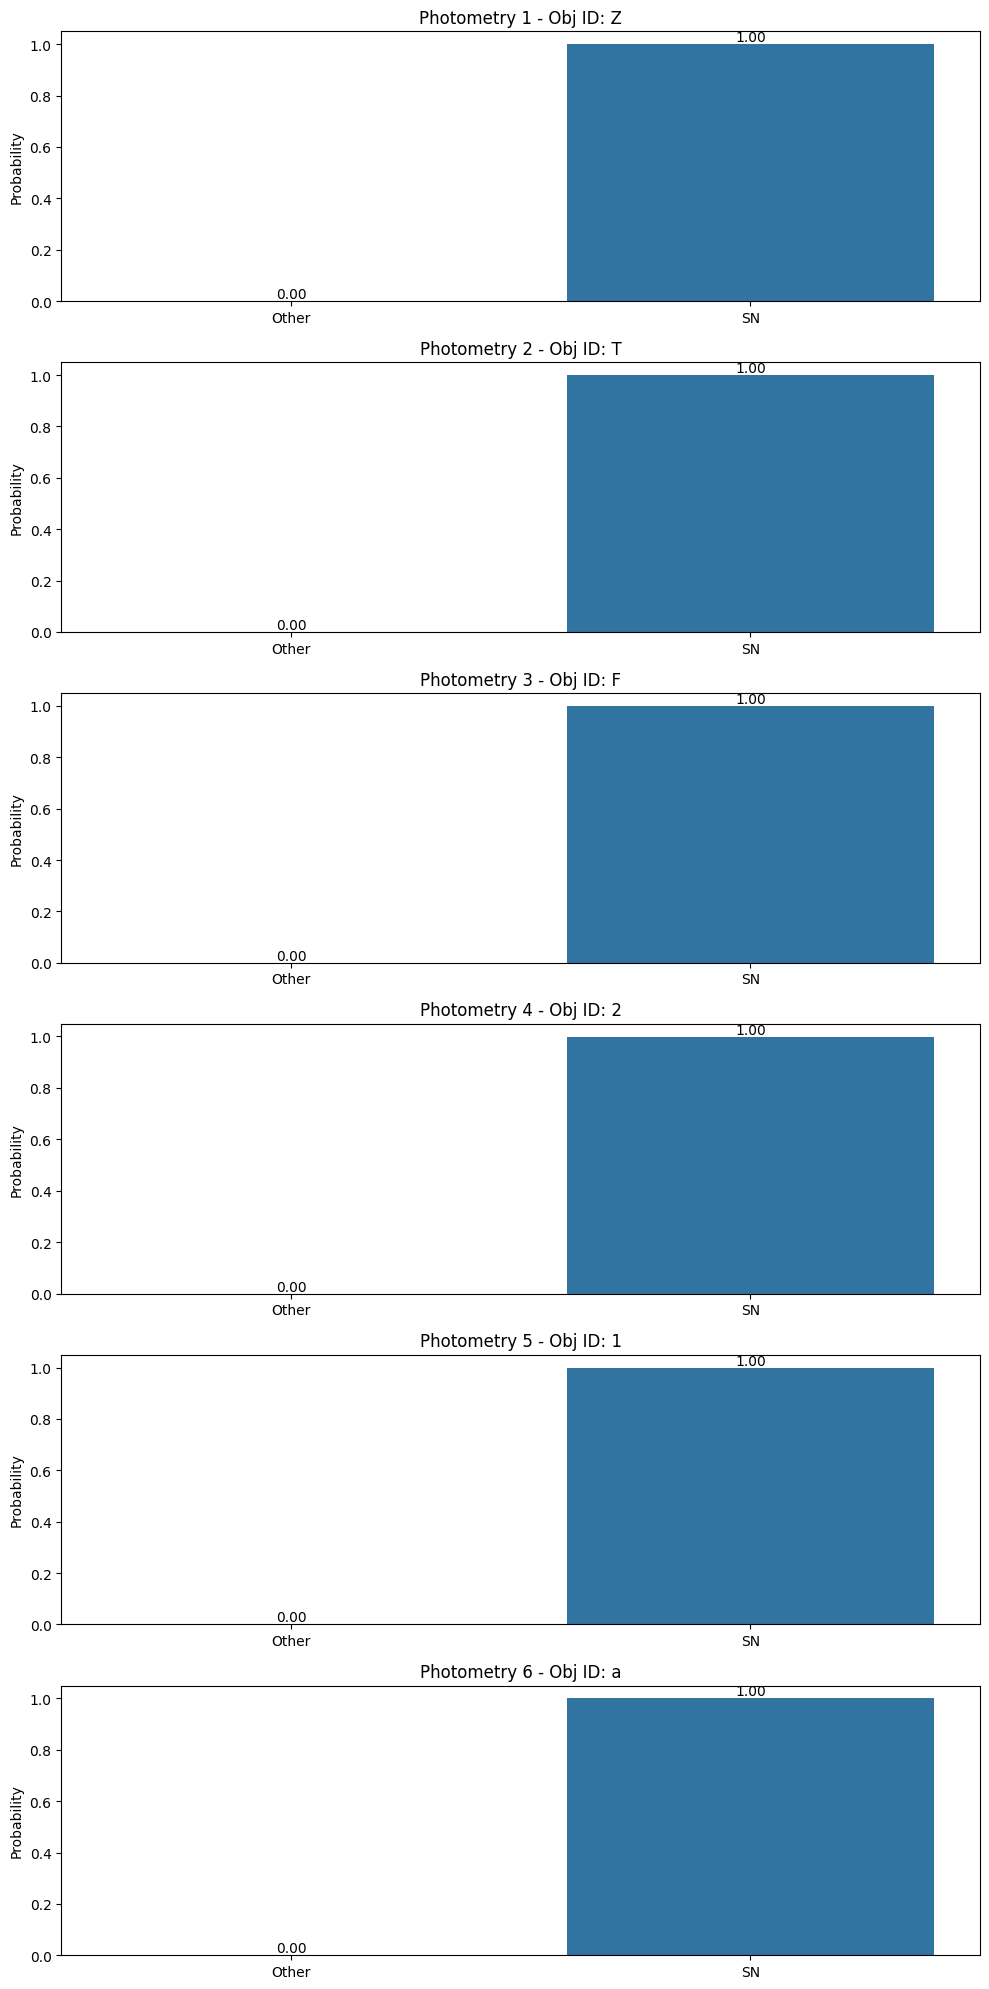

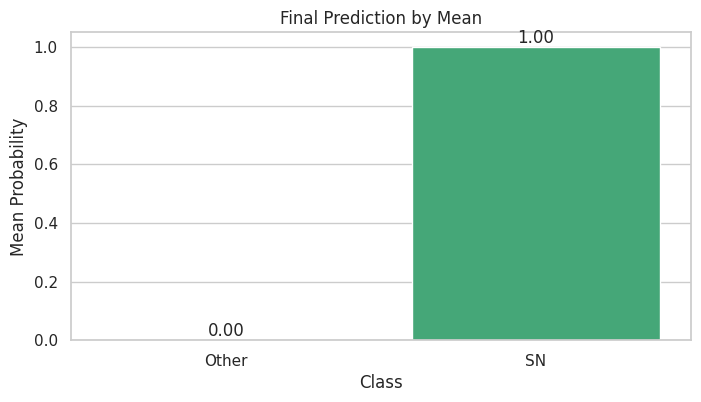

Final Prediction by Mean: [8.30232004e-06 9.99805686e-01]
Final Class by Voting: SN


In [93]:
types = ['Other', 'SN']

# Display predictions
display_predictions(y_pred, objId, types)
# Calculate and display the weighted average prediction
weights = np.array([0.4, 0.15, 0.15, 0.1, 0.1, 0.05, 0.05])

weights = weights[:y_pred.shape[0]]

final_prediction = weighted_average_predictions(y_pred, weights)
if final_prediction is not None:
    final_prediction_display(final_prediction, types)
    final_class = np.argmax(final_prediction)
    print(f"Final Prediction by Mean:", final_prediction)
    print(f"Final Class by Voting:", types[final_class])
else:
    print("No valid predictions available.")

In [23]:
photo_df, cand, triplets, objIds = load_all_data('data/photometry_Other_SN_I_SN_II.csv', 'data/train_cand_ZTFSS.csv', 'data/train_triplets_ZTFSS.npy')

In [32]:
# all

#objId = 'ZTF21abiacoi'
objId = get_objId(objIds)
one_photo, one_cand, one_image = get_data(objId, photo_df, cand, triplets)

real_type = one_photo['type'].iloc[0]
print(f"Real Type: {real_type}")

photo_ready, cand_ready, image_ready = process_data(one_photo, one_cand, one_image)
photo_ready.head()

final_data = predict_classes(photo_ready, cand_ready, image_ready)

y_pred, y_pred_classes = predict_T2(final_data, model)

display_predictions(y_pred, objId, types)

weights = np.array([0.4, 0.15, 0.15, 0.1, 0.1, 0.05, 0.05])
weights = weights[:y_pred.shape[0]]
types = ['Other', 'SN']

final_prediction = weighted_average_predictions(y_pred, weights)
if final_prediction is not None:
    final_prediction_display(final_prediction, types)
    final_class = np.argmax(final_prediction)
    print(f"Final Prediction by Mean:", final_prediction)
    print(f"Final Class by Voting:", types[final_class])
else:
    print("No valid predictions available.")

print(f'Predicted Type: {types[final_class]} | Real Type: {real_type}')

Real Type: Other


AttributeError: type object 'tqdm' has no attribute 'tqdm'

In [51]:
# prend la moitié de objIds

obj_ids = objIds[:1000]

In [52]:
from tqdm import tqdm

def calculate_success_rate(objIds, photo_df, cand, triplets, model):
    total_objects = len(objIds)
    successful_predictions = 0
    successful_high_confidence_predictions = 0
    high_confidence_predictions = 0
    incorrect_predictions = []
    confidence_correct = []
    confidence_incorrect = []
    logs = []

    types = ['Other', 'SN']
    weights = np.array([0.6, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
    weights = weights / np.sum(weights)  # Normaliser les poids

    for objId in tqdm(objIds, desc="Processing Objects"):
        try:
            one_photo, one_cand, one_image = get_data(objId, photo_df, cand, triplets)
            
            real_type = one_photo['type'].iloc[0].split()[0]

            photo_ready, cand_ready, image_ready = process_data(one_photo, one_cand, one_image)

            final_data = predict_classes(photo_ready, cand_ready, image_ready)

            y_pred, y_pred_classes = predict_T2(final_data, model)

            if y_pred.size == 0:
                logs.append(f"No valid predictions available for objId: {objId}")
                continue

            final_prediction = weighted_average_predictions(y_pred, weights)
            if final_prediction is not None:
                final_class = np.argmax(final_prediction)
                prediction_type = types[final_class]
                confidence = final_prediction[final_class]
                success = prediction_type == real_type
                status = 'V' if success else 'X'
                logs.append(f"{status} | Final Prediction: {final_prediction} | Predicted: {prediction_type} | Real: {real_type} | Confidence: {confidence:.2f}")
                if success:
                    successful_predictions += 1
                    confidence_correct.append(confidence)
                    if confidence > 0.6:
                        successful_high_confidence_predictions += 1
                else:
                    incorrect_predictions.append((final_prediction, prediction_type, real_type))
                    confidence_incorrect.append(confidence)
                if confidence > 0.6:
                    high_confidence_predictions += 1
            else:
                logs.append(f"X | No valid predictions available for objId: {objId}")
        except Exception as e:
            logs.append(f"Error processing objId {objId}: {e}")
            
    success_rate = (successful_predictions / total_objects) * 100 if total_objects > 0 else 0
    high_confidence_success_rate = (successful_high_confidence_predictions / high_confidence_predictions) * 100 if high_confidence_predictions > 0 else 0
    average_confidence_correct = np.mean(confidence_correct) if confidence_correct else 0
    average_confidence_incorrect = np.mean(confidence_incorrect) if confidence_incorrect else 0

    summary = [
        f"Success Rate: {success_rate}%",
        f"Success Rate for High Confidence Predictions (>70%): {high_confidence_success_rate}%",
        f"Average Confidence for Correct Predictions: {average_confidence_correct:.2f}",
        f"Average Confidence for Incorrect Predictions: {average_confidence_incorrect:.2f}"
    ]

    if incorrect_predictions:
        summary.append("\nIncorrect Predictions Analysis:")
        for pred, predicted, real in incorrect_predictions:
            summary.append(f"Predicted: {predicted}, Real: {real}, Prediction: {pred}")

    return success_rate, high_confidence_success_rate, average_confidence_correct, average_confidence_incorrect, logs, summary

success_rate, high_confidence_success_rate, avg_conf_correct, avg_conf_incorrect, logs, summary = calculate_success_rate(obj_ids, photo_df, cand, triplets, model)


100%|██████████| 1/1 [00:00<00:00, 130.36it/s]0:00<?, ?it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


100%|██████████| 1/1 [00:00<00:00, 99.31it/s]00:00<09:29,  1.75it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


100%|██████████| 1/1 [00:00<00:00, 95.05it/s]00:01<11:31,  1.44it/s]


...

100%|██████████| 1/1 [00:00<00:00, 80.35it/s] [17:51<00:01,  1.51it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


100%|██████████| 1/1 [00:00<00:00, 132.71it/s][17:52<00:00,  1.39it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


Processing Objects: 100%|██████████| 1000/1000 [17:53<00:00,  1.07s/it]


In [53]:
for i in summary:
    print(i)

print(success_rate, high_confidence_success_rate, avg_conf_correct, avg_conf_incorrect)

Success Rate: 74.9%
Success Rate for High Confidence Predictions (>70%): 77.52688172043011%
Average Confidence for Correct Predictions: 0.81
Average Confidence for Incorrect Predictions: 0.74

Incorrect Predictions Analysis:
Predicted: SN, Real: Other, Prediction: [0.22940764 0.77553326]
Predicted: SN, Real: Other, Prediction: [0.46082412 0.55347818]
Predicted: SN, Real: Other, Prediction: [0.18368554 0.81869468]
Predicted: SN, Real: Other, Prediction: [0.36162767 0.65059815]
Predicted: SN, Real: Other, Prediction: [0.36244585 0.66259521]
Predicted: SN, Real: Other, Prediction: [0.18935658 0.8200744 ]
Predicted: SN, Real: Other, Prediction: [0.26109883 0.74439682]
Predicted: SN, Real: Other, Prediction: [0.22857034 0.77195372]
Predicted: SN, Real: Other, Prediction: [0.36350918 0.67013268]
Predicted: SN, Real: Other, Prediction: [0.16206242 0.84394447]
Predicted: SN, Real: Other, Prediction: [0.2668519  0.73748783]
Predicted: SN, Real: Other, Prediction: [0.15365788 0.85767777]
Predict

In [50]:
import numpy as np
from tqdm import tqdm

def calculate_success_rate(objIds, photo_df, cand, triplets, model):
    total_objects = len(objIds)
    all_predictions = []

    types = ['Other', 'SN']
    weights = np.array([0.6, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
    weights = weights / np.sum(weights)  # Normaliser les poids

    for objId in tqdm(objIds, desc="Processing Objects"):
        try:
            one_photo, one_cand, one_image = get_data(objId, photo_df, cand, triplets)
            real_type = one_photo['type'].iloc[0].split()[0]

            photo_ready, cand_ready, image_ready = process_data(one_photo, one_cand, one_image)
            final_data = predict_classes(photo_ready, cand_ready, image_ready)
            y_pred, y_pred_classes = predict_T2(final_data, model)

            if y_pred.size == 0:
                continue

            final_prediction = weighted_average_predictions(y_pred, weights)
            if final_prediction is not None:
                final_class = np.argmax(final_prediction)
                prediction_type = types[final_class]
                confidence = final_prediction[final_class]
                success = prediction_type == real_type
                all_predictions.append((final_prediction, success))
        except Exception as e:
            print(f"Error processing objId {objId}: {e}")
            
    return all_predictions

# Exemple d'appel de la fonction
all_predictions = calculate_success_rate(obj_ids, photo_df, cand, triplets, model)

def analyze_thresholds(predictions, thresholds):
    results = []
    for threshold in thresholds:
        total_predictions = len(predictions)
        successful_predictions = 0
        high_confidence_predictions = 0

        for final_prediction, success in predictions:
            confidence = max(final_prediction)  # Calcul de la confiance pour la classe prédite
            if confidence > threshold:
                high_confidence_predictions += 1
                if success:  # Utiliser le succès pour déterminer si la prédiction est correcte
                    successful_predictions += 1
        
        success_rate = (successful_predictions / total_predictions) * 100 if total_predictions > 0 else 0
        high_confidence_success_rate = (successful_predictions / high_confidence_predictions) * 100 if high_confidence_predictions > 0 else 0
        
        results.append({
            'threshold': threshold,
            'success_rate': success_rate,
            'high_confidence_success_rate': high_confidence_success_rate,
            'total_predictions': total_predictions,
            'successful_predictions': successful_predictions,
            'high_confidence_predictions': high_confidence_predictions
        })
    return results

thresholds = np.arange(0.0, 1.0, 0.05)
analysis_results = analyze_thresholds(all_predictions, thresholds)

# Affichage des résultats
for result in analysis_results:
    print(f"Threshold: {result['threshold']:.2f}, Success Rate: {result['success_rate']:.2f}%, High Confidence Success Rate: {result['high_confidence_success_rate']:.2f}%")


100%|██████████| 1/1 [00:00<00:00, 106.70it/s]:00<?, ?it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


Processing Objects:   1%|          | 1/100 [00:00<00:55,  1.80it/s]

Error processing objId ZTF20aautfqu: boolean index did not match indexed array along dimension 0; dimension is 7 but corresponding boolean dimension is 6


100%|██████████| 1/1 [00:00<00:00, 106.60it/s]


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


100%|██████████| 1/1 [00:00<00:00, 108.32it/s]2:11<00:01,  1.02s/it]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


Processing Objects: 100%|██████████| 100/100 [02:14<00:00,  1.35s/it]

Threshold: 0.00, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.05, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.10, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.15, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.20, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.25, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.30, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.35, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.40, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.45, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.50, Success Rate: 74.23%, High Confidence Success Rate: 74.23%
Threshold: 0.55, Success Rate: 74.23%, High Confidence Success Rate: 75.00%
Threshold: 0.60, Success Rate: 74.23%, High Confidence Success Rate: 76.60%
Threshold: 0

In [48]:
print(all_predictions)

[(array([0.07161287, 0.93181724]), True), (array([0.19007908, 0.81417049]), False), (array([0.27287246, 0.73157865]), True), (array([0.06792064, 0.93923738]), True), (array([0.25085991, 0.76703618]), True), (array([0.21943864, 0.78795536]), True), (array([0.27013855, 0.73507688]), True), (array([0.11625797, 0.88741526]), True), (array([0.16081572, 0.84336068]), True), (array([0.16833921, 0.84548251]), True), (array([0.75384121, 0.24457114]), True), (array([0.44633834, 0.56768552]), False), (array([0.24898441, 0.75546945]), False), (array([0.26784755, 0.73896635]), False), (array([0.14035851, 0.864301  ]), True), (array([0.14610721, 0.85986372]), True), (array([0.19705869, 0.80502119]), True), (array([0.28962506, 0.71904604]), True), (array([0.16417875, 0.84679359]), True), (array([0.15396777, 0.85502837]), True), (array([0.38717103, 0.62670527]), True), (array([0.25067871, 0.75514673]), True), (array([0.16283159, 0.84476873]), True), (array([0.22599103, 0.78811283]), True), (array([0.1